In [1]:
import json
import os
import pathlib
import sqlite3
import sys

from IPython.display import display, Markdown
import dns.message
import matplotlib.pyplot
import matplotlib.style
import numpy
import polars

COLLECT_JSONS_DIR = pathlib.Path.cwd()

os.environ["COLLECT_JSONS_DIR"] = str(COLLECT_JSONS_DIR)
if str(COLLECT_JSONS_DIR) not in sys.path:
    sys.path.append(str(COLLECT_JSONS_DIR))

# [JSON request/responses](../plots/json_responses_cdf.pdf)

<Figure size 158.526x123.758 with 0 Axes>

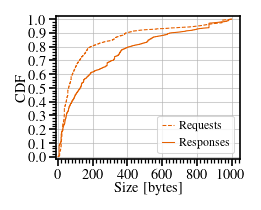

# [CBOR request/responses](../plots/cbor_responses_cdf.pdf)

<Figure size 158.526x123.758 with 0 Axes>

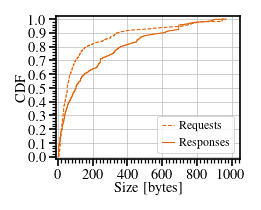

# [Classic DNS queries/responses](../plots/dns_messages_cdf.pdf)

<Figure size 158.526x123.758 with 0 Axes>

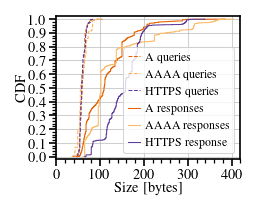

# [CBOR DNS queries/responses](../plots/dns_cbor_cdf.pdf)

<Figure size 158.526x123.758 with 0 Axes>

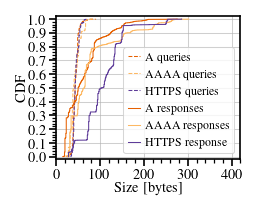

In [2]:
PLOT_DIR = COLLECT_JSONS_DIR / ".." / "plots"

matplotlib.style.use(COLLECT_JSONS_DIR / ".." / "mlenders_halfcolumn.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0] * 0.95,
    matplotlib.rcParams["figure.figsize"][1] * 1.2,
)
matplotlib.rcParams["axes.prop_cycle"] = matplotlib.pyplot.cycler(
    "color",
    ['#e66101', '#fdb863', '#5e3c99'],
    # matplotlib.colormaps["Set2"].colors,
)

with sqlite3.connect(COLLECT_JSONS_DIR / "2024-09-01-sample.sqlite3") as db:
    df = polars.read_database("""
        SELECT
            LENGTH(json_query) as json_query_len,
            LENGTH(cbor_query) as cbor_query_len,
            LENGTH(json) as json_len,
            LENGTH(cbor) as cbor_len
        FROM objects
        WHERE LENGTH(json_query) <= 1000""", db)

for typ in ["json", "cbor"]:
    matplotlib.pyplot.clf()
    fig = matplotlib.pyplot.figure(figsize=matplotlib.rcParams["figure.figsize"], dpi=150)
    # print(dns.message.from_wire(bytes.fromhex(df["a_r_dns_msg"][0])).to_text())
    ax = matplotlib.pyplot.gca()
    matplotlib.pyplot.ecdf(
        df[f"{typ}_query_len"],
        color="C0",
        linestyle="--",
        markevery=(0.000, 0.05),
        label=f"Requests",
        linewidth=0.5,
    )
    matplotlib.pyplot.ecdf(
        df[f"{typ}_len"],
        color="C0",
        markevery=(0.025, 0.05),
        label=f"Responses",
        linewidth=0.5,
    )
    ax.set_xlim((-10, 1050))
    ax.set_xticks(numpy.arange(0, 1050, 200))
    ax.set_xticks(numpy.arange(0, 1051, 20), minor=True)
    ax.set_ylim((-0.02, 1.02))
    ax.set_yticks(numpy.arange(0, 1.1, 0.1))
    ax.set_yticks(numpy.arange(0, 1.01, 0.02), minor=True)
    # ax.ticklabel_format(axis='y', style='sci', scilimits=(-3,-3))
    ax.set_xlabel("Size [bytes]")
    ax.set_ylabel("CDF")
    ax.legend(loc="lower right", fontsize="xx-small")
    ax.grid()
    
    filename = PLOT_DIR / f"{typ}_responses_cdf.pdf"
    display(Markdown(f"# [{typ.upper()} request/responses](../{filename.resolve().relative_to((PLOT_DIR / '..').resolve())})"))
    matplotlib.pyplot.savefig(filename, bbox_inches="tight", pad_inches=0.01)
    matplotlib.pyplot.show()

with sqlite3.connect(COLLECT_JSONS_DIR / "2024-09-01-sample.sqlite3") as db:
    dns_df = polars.read_database("""
        SELECT
            name,
            type,
            LENGTH(classic_query) as classic_query_len,
            LENGTH(cbor_query) as cbor_query_len,
            LENGTH(classic_response) as classic_response_len,
            LENGTH(cbor_response) as cbor_response_len,
            obj_id
        FROM dns
        WHERE obj_id in (
            SELECT id
            FROM objects
            WHERE LENGTH(json_query) <= 1000
        )""", db)


https = dns_df.filter(
    polars.col("type") == "HTTPS"
)[
    "name",
    "classic_query_len",
    "classic_response_len",
    "cbor_query_len",
    "cbor_response_len",
]
aaaa = dns_df.filter(
    (polars.col("type") == "AAAA")
    & ~polars.col("name").is_in(https["name"].implode())
)[
    "name",
    "classic_query_len",
    "classic_response_len",
    "cbor_query_len",
    "cbor_response_len",
]
a = dns_df.filter(
    (polars.col("type") == "A") 
    & ~polars.col("name").is_in(https["name"].implode())
    & ~polars.col("name").is_in(aaaa["name"].implode())
)[
    "name",
    "classic_query_len",
    "classic_response_len",
    "cbor_query_len",
    "cbor_response_len",
]

for typ in ["classic", "cbor"]:
    matplotlib.pyplot.clf()
    matplotlib.style.use(COLLECT_JSONS_DIR / ".." / "mlenders_halfcolumn.mplstyle")
    matplotlib.rcParams["figure.figsize"] = (
        matplotlib.rcParams["figure.figsize"][0] * 0.95,
        matplotlib.rcParams["figure.figsize"][1] * 1.2,
    )
    fig = matplotlib.pyplot.figure(figsize=matplotlib.rcParams["figure.figsize"], dpi=150)
    
    ax = matplotlib.pyplot.gca()
    
    matplotlib.pyplot.ecdf(
        a[f"{typ}_query_len"],
        color="C0",
        linestyle="--",
        label="A queries",
        linewidth=0.5,
    )
    matplotlib.pyplot.ecdf(
        aaaa[f"{typ}_query_len"],
        color="C1",
        linestyle="--",
        label="AAAA queries",
        linewidth=0.5,
    )
    matplotlib.pyplot.ecdf(
        https[f"{typ}_query_len"],
        color="C2",
        linestyle="--",
        label="HTTPS queries",
        linewidth=0.5,
    )
    matplotlib.pyplot.ecdf(
        a[f"{typ}_response_len"],
        color="C0",
        label="A responses",
        linewidth=0.5,
    )
    matplotlib.pyplot.ecdf(
        aaaa[f"{typ}_response_len"],
        color="C1",
        label="AAAA responses",
        linewidth=0.5,
    )
    matplotlib.pyplot.ecdf(
        https[f"{typ}_response_len"],
        color="C2",
        label="HTTPS response",
        linewidth=0.5,
    )
    ax.set_xlim((0, 420))
    ax.set_xticks(numpy.arange(0, 420, 100))
    ax.set_xticks(numpy.arange(0, 421, 20), minor=True)
    ax.set_ylim((-0.02, 1.02))
    ax.set_yticks(numpy.arange(0, 1.1, 0.1))
    ax.set_yticks(numpy.arange(0, 1.01, 0.02), minor=True)
    ax.set_xlabel("Size [bytes]")
    ax.set_ylabel("CDF")
    ax.legend(loc="lower right", fontsize="xx-small")
    ax.grid()
    
    filename = PLOT_DIR / f"dns_{'messages' if typ == 'classic' else typ}_cdf.pdf"
    display(Markdown(f"# [{typ.upper() if typ == 'cbor' else typ.title()} DNS queries/responses](../{filename.resolve().relative_to((PLOT_DIR / '..').resolve())})"))
    matplotlib.pyplot.savefig(filename, bbox_inches="tight", pad_inches=0.01)
    matplotlib.pyplot.show()

In [3]:
polars.DataFrame(
    [
        ("Total JSONs", df.shape[0]),
        ("HTTPS records for JSONs", dns_df.filter(polars.col("type") == "HTTPS").shape[0]),
        ("AAAA records for JSONs", dns_df.filter(polars.col("type") == "AAAA").shape[0]),
        ("A records for JSONs", dns_df.filter(polars.col("type") == "A").shape[0]),
        ("!HTTPS & AAAA record", aaaa.shape[0]),
        ("!HTTPS & !AAAA & A record", a.shape[0]),
        (
            "HTTPS & AAAA record",
            dns_df.filter(polars.col("type") == "HTTPS")["name", "type", "obj_id"].join(
                dns_df.filter(polars.col("type") == "AAAA")["name", "type", "obj_id"],
                on=["name", "obj_id"],
                how="inner",
            ).shape[0]
        ),
    ],
    schema=["label", "count"],
    orient="row",
).to_pandas().set_index(["label"])

,count
label,
Total JSONs,25205
HTTPS records for JSONs,4780
AAAA records for JSONs,10268
A records for JSONs,25205
!HTTPS & AAAA record,5953
!HTTPS & !AAAA & A record,14472
HTTPS & AAAA record,4315


In [4]:
df.quantile(.8)

json_query_len,cbor_query_len,json_len,cbor_len
f64,f64,f64,f64
189.0,165.0,414.0,362.0


In [5]:
dns_df["classic_query_len", "cbor_query_len", "classic_response_len", "cbor_response_len"].quantile(.99)

classic_query_len,cbor_query_len,classic_response_len,cbor_response_len
f64,f64,f64,f64
83.0,68.0,313.0,232.0


In [6]:
dns_df["classic_query_len", "cbor_query_len", "classic_response_len", "cbor_response_len"].max()

classic_query_len,cbor_query_len,classic_response_len,cbor_response_len
i64,i64,i64,i64
105,90,404,302
